# Google Trends Analysis of Belarusian and Russian Search Queries 

This notebook uses Google Trends data to compare search interest in Russian-language and Belarusian-language query forms in Belarus from 2015 to 2025. 

The analysis has two main parts: 

1. comparing everyday Russian and Belarusian search terms;
2. measuring interest in Belarusian language, culture, history, and identity.

## 1. Installing and importing libraries 

The notebook uses `pytrends` to collect Google Trends data, `pandas` to

In [1]:
#%pip install pytrends pandas matplotlib tqdm

## 2. Checking that Google Trends responds

Before collecting the full dataset, I test the connection to Google Trends with two simple queries: `новости` and `навіны`. 

This confirms that `pytrends` can return data for Belarus before running longer collection loops.

In [1]:
from pytrends.request import TrendReq

pytrends = TrendReq(
    hl='ru-RU',
    tz=180
)

pytrends.build_payload(
    ['новости', 'навіны'],
    timeframe='today 5-y',
    geo='BY'
)

df = pytrends.interest_over_time()

print(df.head())
print(df.shape)

            новости  навіны  isPartial
date                                  
2021-06-20       38       0      False
2021-06-27       40       0      False
2021-07-04       42       0      False
2021-07-11       41       0      False
2021-07-18       37       0      False
(262, 3)


## 3. Creating Russian–Belarusian query pairs

I define a list of 36 paired everyday search terms, where each pair contains one Russian-language form and one Belarusian-language form.

I create a list of equivalent Russian and Belarusian search terms representing common everyday topics such as work, education, healthcare, shopping, housing, and news.

These pairs will be used to compare the relative popularity of Russian- and Belarusian-language searches over time.

In [2]:
pairs = [

("работа","праца"),
("вакансии","вакансіі"),
("зарплата","заробак"),
("деньги","грошы"),
("магазин","крама"),
("скидки","зніжкі"),

("детский сад","дзіцячы садок"),
("университет","універсітэт"),
("учитель","настаўнік"),
("студент","студэнт"),
("образование","адукацыя"),

("квартира","кватэра"),
("ремонт","рамонт"),
("мебель","мэбля"),
("рецепт","рэцэпт"),
("цены","цэны"),

("погода","надвор'е"),
("телефон","тэлефон"),
("доставка","дастаўка"),

("врач","лекар"),
("больница","бальніца"),
("аптека","аптэка"),
("лекарство","лекі"),
("здоровье","здароўе"),

("новости","навіны"),
("паспорт","пашпарт"),
("виза","віза"),
("граница","мяжа"),
("транспорт","транспарт"),

("работа за границей","праца за мяжой"),
("расписание","расклад"),
("экзамен","іспыт"),
("учебник","падручнік"),
("поликлиника","паліклініка"),
("анализы","аналізы"),
("стоматолог","стаматолаг")

]

## 4. Collecting yearly Google Trends data

For each Russian–Belarusian pair, I request Google Trends data for Belarus covering the period from 2015 to 2025.

The weekly observations returned by Google Trends are aggregated into yearly averages. 

I then calculate the total yearly search interest for Russian and Belarusian terms, compute the Belarusian-language share, and store the results in a dataframe. A short pause is added between requests to avoid exceeding Google Trends rate limits.

In [3]:
from pytrends.request import TrendReq
import pandas as pd
import time

pytrends = TrendReq(
    hl='ru-RU',
    tz=180
)

records = []

for ru, be in pairs:

    print(ru, be)

    try:

        pytrends.build_payload(
            [ru, be],
            timeframe='2015-01-01 2025-12-31',
            geo='BY'
        )

        df = pytrends.interest_over_time()

        if len(df) == 0:
            continue

        df["year"] = df.index.year

        yearly = (
            df.groupby("year")[[ru, be]]
            .mean()
            .reset_index()
        )

        for _, row in yearly.iterrows():

            records.append({
                "year": row["year"],
                "ru": row[ru],
                "be": row[be]
            })

        time.sleep(10)

    except Exception as e:
        print(e)

final = pd.DataFrame(records)

yearly = (
    final
    .groupby("year")[["ru", "be"]]
    .sum()
    .reset_index()
)

yearly["be_share"] = (
    yearly["be"] /
    (yearly["ru"] + yearly["be"])
) * 100

yearly

работа праца
вакансии вакансіі
зарплата заробак
деньги грошы
магазин крама
скидки зніжкі
детский сад дзіцячы садок
университет універсітэт
учитель настаўнік
студент студэнт
образование адукацыя
квартира кватэра
ремонт рамонт
мебель мэбля
рецепт рэцэпт
цены цэны
погода надвор'е
телефон тэлефон
доставка дастаўка
врач лекар
больница бальніца
аптека аптэка
лекарство лекі
здоровье здароўе
новости навіны
паспорт пашпарт
виза віза
граница мяжа
транспорт транспарт
работа за границей праца за мяжой
расписание расклад
экзамен іспыт
учебник падручнік
поликлиника паліклініка
анализы аналізы
стоматолог стаматолаг


,year,ru,be,be_share
0,2015.0,1781.000000,4.166667,0.233405
1,2016.0,1861.750000,4.000000,0.214391
2,2017.0,1961.250000,3.500000,0.178140
3,2018.0,2040.416667,2.666667,0.130522
4,2019.0,2127.833333,3.416667,0.160313
5,2020.0,2202.083333,3.166667,0.143597
6,2021.0,2309.916667,3.083333,0.133305
7,2022.0,2306.250000,3.166667,0.137120
8,2023.0,2346.750000,2.750000,0.117046
9,2024.0,2238.916667,3.833333,0.170921


## 5. Saving the yearly language comparison

The aggregated yearly statistics are exported as a CSV file.

In [4]:
yearly.to_csv(
    "belarus_language_share_by_year.csv",
    index=False
)

## 6. Visualizing the Belarusian-language share

This chart shows how the proportion of Belarusian-language search queries changed between 2015 and 2025.

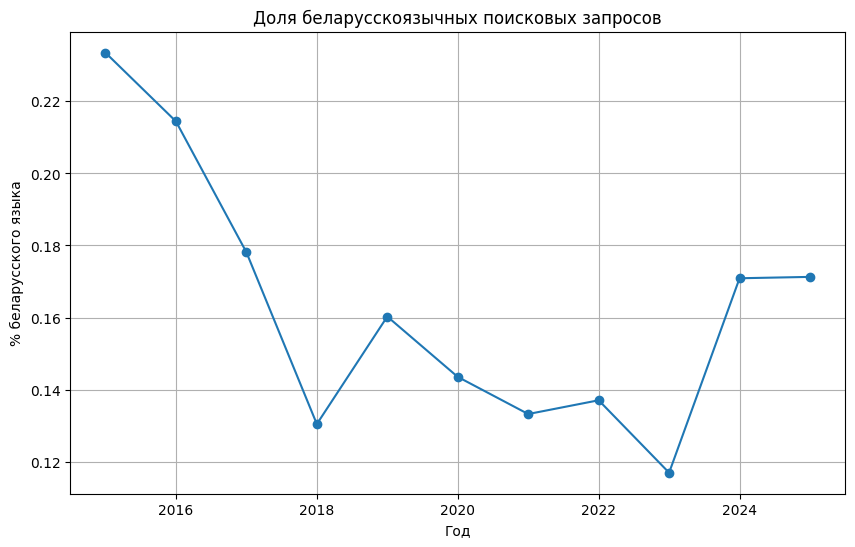

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.plot(
    yearly["year"],
    yearly["be_share"],
    marker="o"
)

plt.title(
    "Доля беларусскоязычных поисковых запросов"
)

plt.xlabel("Год")
plt.ylabel("% беларусского языка")

plt.grid(True)

plt.show()

Colclusion: the relative representation of Belarusian-language forms in the sample declined compared to the mid-2010s and only partially recovered in 2024–2025.

## 7. Comparing Russian and Belarusian search volumes

This figure plots the yearly Google Trends index for Russian- and Belarusian-language search terms, allowing a direct comparison between the two languages.

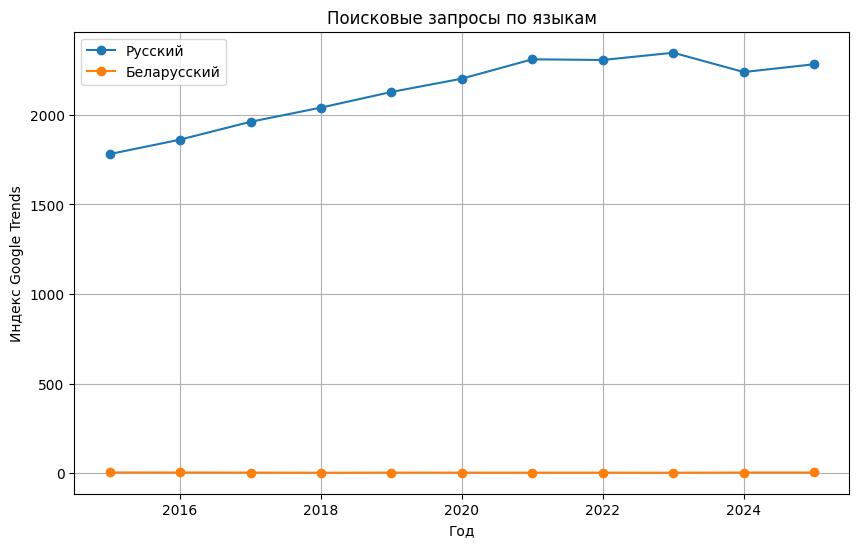

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.plot(
    yearly["year"],
    yearly["ru"],
    marker="o",
    label="Russian"
)

plt.plot(
    yearly["year"],
    yearly["be"],
    marker="o",
    label="Belarusian"
)

plt.title(
    "Search queries by language"
)

plt.xlabel("Год")
plt.ylabel("Индекс Google Trends")

plt.legend()

plt.grid(True)

plt.show()

Colclusion: Belarusian-language search query forms consistently trail behind Russian-language ones throughout the entire 2015–2025 period.

## 8. Calculating the Russian-to-Belarusian ratio

To better illustrate the language gap, I calculate how many times larger Russian-language search interest is compared with Belarusian-language search interest for each year.

In [8]:
yearly["ru_to_be"] = yearly["ru"] / yearly["be"]

In [9]:
print(
    yearly[["year","ru_to_be"]]
)

      year    ru_to_be
0   2015.0  427.440000
1   2016.0  465.437500
2   2017.0  560.357143
3   2018.0  765.156250
4   2019.0  622.780488
5   2020.0  695.394737
6   2021.0  749.162162
7   2022.0  728.289474
8   2023.0  853.363636
9   2024.0  584.065217
10  2025.0  582.765957


Conclusion:

Based on the selected set of everyday search queries:

- in 2015, Russian-language forms were searched for approximately 427 times more often than Belarusian-language ones;
- by 2023, the gap had widened to 853 times;
- in 2024–2025, a noticeable narrowing of the gap to approximately 580 times is observed.

All in all, in our sample of 36 pairs of everyday search queries, Russian-language forms consistently dominated over Belarusian-language ones, and the relative gap between them widened until 2023.

## 9. Saving the raw yearly data

The complete yearly dataset for every Russian–Belarusian search pair is exported for future analysis.

In [10]:
final.to_csv(
    "belarus_language_raw_pairs.csv",
    index=False
)

## 10. Visualizing the language ratio

This chart displays the yearly ratio of Russian-language to Belarusian-language searches, highlighting how dominant Russian-language queries remain over time.

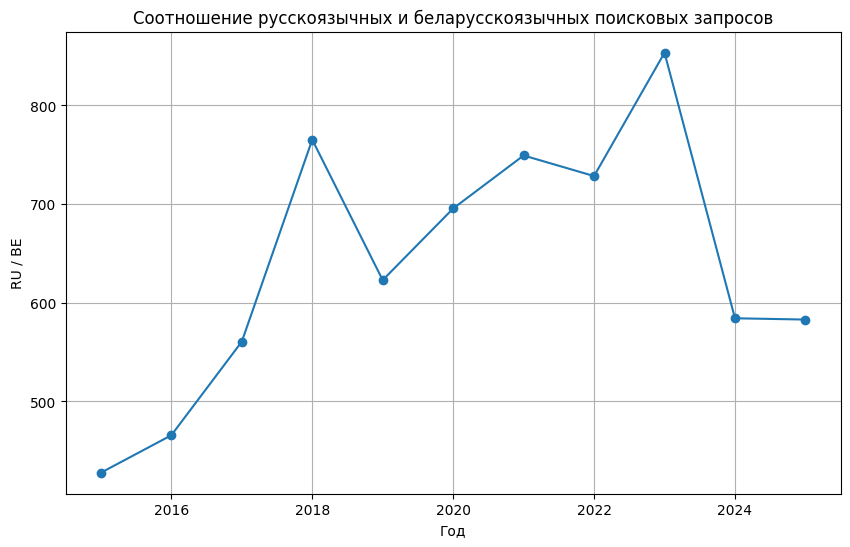

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.plot(
    yearly["year"],
    yearly["ru_to_be"],
    marker="o"
)

plt.title(
    "Соотношение русскоязычных и беларусскоязычных поисковых запросов"
)

plt.xlabel("Год")
plt.ylabel("RU / BE")

plt.grid(True)

plt.show()

## 11. Defining identity-related search terms

In addition to everyday vocabulary, I compile a second dataset consisting of search terms related to Belarusian language, literature, culture, history, and national identity.

These terms are used to measure changes in public interest in Belarusian cultural identity.

In [13]:
language_terms = [
    "беларуская мова",
    "беларускі слоўнік",
    "перакладчык",
    "пераклад",
    "тарашкевіца",
    "наркамаўка",
    "курсы беларускай мовы",
    "вывучыць беларускую мову",
    "правілы беларускай мовы",
    "граматыка"
]

literature_terms = [
    "Янка Купала",
    "Якуб Колас",
    "Уладзімір Караткевіч",
    "Васіль Быкаў",
    "Максім Багдановіч",
    "Рыгор Барадулін"
]

culture_terms = [
    "вышыванка",
    "беларускія песні",
    "беларуская літаратура",
    "беларуская культура",
    "беларускія традыцыі",
    "купалле",
    "дударскі фэст"
]

history_terms = [
    "ВКЛ",
    "Вялікае княства Літоўскае",
    "Кастусь Каліноўскі",
    "БНР",
    "Слуцкі збройны чын",
    "Пагоня",
    "бел-чырвона-белы сцяг"
]

identity_terms = [
    "беларус",
    "беларусы",
    "Беларушчына",
    "беларуская музыка",
    "беларускія гурты",
    "Лявон Вольскі",
    "NRM",
    "Мроя"
]

In [14]:
terms = (
    language_terms
    + literature_terms
    + culture_terms
    + history_terms
    + identity_terms
)

## 12. Collecting Google Trends data for identity-related terms

For each identity-related search term, I collect Google Trends data for Belarus between 2015 and 2025.

The weekly observations are averaged by year and stored in a dataframe for later aggregation.

In [15]:
# Test to collect one term data

pytrends.build_payload(
    ["беларуская мова"],
    timeframe="2015-01-01 2025-12-31",
    geo="BY"
)

In [16]:
from pytrends.request import TrendReq
import pandas as pd
import time

pytrends = TrendReq(
    hl="ru-RU",
    tz=180
)

records = []

for term in terms:

    try:

        print(term)

        pytrends.build_payload(
            [term],
            timeframe="2015-01-01 2025-12-31",
            geo="BY"
        )

        df = pytrends.interest_over_time()

        if len(df) == 0:
            continue

        df["year"] = df.index.year

        yearly = (
            df.groupby("year")[term]
            .mean()
            .reset_index()
        )

        for _, row in yearly.iterrows():

            records.append({
                "term": term,
                "year": row["year"],
                "interest": row[term]
            })

        time.sleep(10)

    except Exception as e:
        print(e)

identity_df = pd.DataFrame(records)

беларуская мова
беларускі слоўнік
перакладчык
пераклад
тарашкевіца
наркамаўка
курсы беларускай мовы
вывучыць беларускую мову
правілы беларускай мовы
граматыка
Янка Купала
Якуб Колас
Уладзімір Караткевіч
Васіль Быкаў
Максім Багдановіч
Рыгор Барадулін
вышыванка
беларускія песні
беларуская літаратура
беларуская культура
беларускія традыцыі
купалле
дударскі фэст
ВКЛ
Вялікае княства Літоўскае
Кастусь Каліноўскі
БНР
Слуцкі збройны чын
Пагоня
бел-чырвона-белы сцяг
беларус
беларусы
Беларушчына
беларуская музыка
беларускія гурты
Лявон Вольскі
NRM
Мроя


## 13. Computing yearly average interest

After collecting all individual search terms, I calculate the average yearly Google Trends index across the entire identity-related dataset.

In [17]:
identity_yearly = (
    identity_df
    .groupby("year")["interest"]
    .mean()
    .reset_index()
)

## 14. Visualizing interest in Belarusian identity

This chart shows how Google search interest in Belarusian language, literature, history, and national identity evolved between 2015 and 2025.

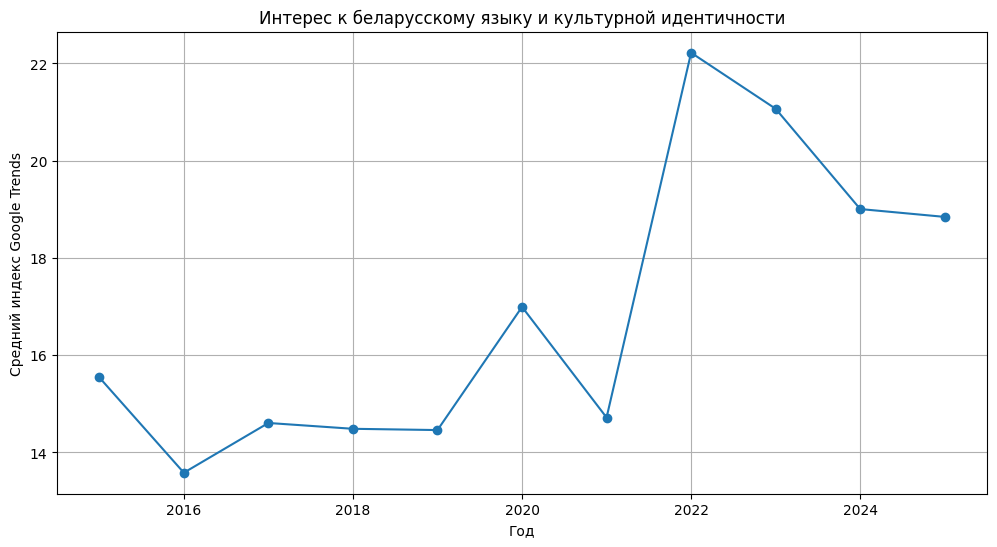

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    identity_yearly["year"],
    identity_yearly["interest"],
    marker="o"
)

plt.title(
    "Интерес к беларусскому языку и культурной идентичности"
)

plt.xlabel("Год")
plt.ylabel("Средний индекс Google Trends")

plt.grid(True)

plt.show()

**Methodological note.** Google Trends provides relative search interest rather than absolute search volumes. The values shown on the chart represent normalized search popularity within Google Trends and should be interpreted as indicators of changing public interest over time rather than the exact number of searches.


## 15. Exporting the identity dataset

The yearly average Google Trends index for identity-related searches is saved as a CSV file.

In [22]:
identity_yearly.to_csv("identity_yearly.csv")

## 16. Testing regional Google Trends data

Before collecting regional statistics for all search terms, I verify that Google Trends returns regional data for a single example query.

In [20]:
from pytrends.request import TrendReq

pytrends = TrendReq(
    hl='ru-RU',
    tz=180
)

pytrends.build_payload(
    ['беларуская мова'],
    timeframe='today 5-y',
    geo='BY'
)

regions = pytrends.interest_by_region(
    resolution='REGION',
    inc_low_vol=True
)

regions.sort_values(
    'беларуская мова',
    ascending=False
).head(20)

,беларуская мова
geoName,
Гомельская область,100
Гродненская область,99
Брестская область,96
Могилёвская область,94
Минская область,93
Витебская область,77


In [21]:
print(regions.shape)
print(regions)

(6, 1)
                     беларуская мова
geoName                             
Брестская область                 96
Витебская область                 77
Гомельская область               100
Гродненская область               99
Минская область                   93
Могилёвская область               94


## 17. Collecting regional search interest

For every identity-related search term, I retrieve Google Trends data by Belarusian region and combine the results into a single dataframe for regional analysis.

In [26]:
pytrends = TrendReq(
    hl="ru-RU",
    tz=180
)

records = []

for term in terms:

    print(term)

    try:

        pytrends.build_payload(
            [term],
            timeframe="today 5-y",
            geo="BY"
        )

        region_df = pytrends.interest_by_region(
            resolution="REGION",
            inc_low_vol=True
        )

        for region, row in region_df.iterrows():

            records.append({
                "region": region,
                "term": term,
                "interest": row[term]
            })

        time.sleep(10)

    except Exception as e:
        print(term, e)

regions_long = pd.DataFrame(records)

regions_long.head()

беларуская мова
беларускі слоўнік
перакладчык
пераклад
тарашкевіца
наркамаўка
курсы беларускай мовы
вывучыць беларускую мову
правілы беларускай мовы
граматыка
Янка Купала
Якуб Колас
Уладзімір Караткевіч
Васіль Быкаў
Максім Багдановіч
Рыгор Барадулін
вышыванка
беларускія песні
беларуская літаратура
беларуская культура
беларускія традыцыі
купалле
дударскі фэст
ВКЛ
Вялікае княства Літоўскае
Кастусь Каліноўскі
БНР
Слуцкі збройны чын
Пагоня
бел-чырвона-белы сцяг
беларус
беларусы
Беларушчына
беларуская музыка
беларускія гурты
Лявон Вольскі
NRM
Мроя


,region,term,interest
0,Брестская область,беларуская мова,96
1,Витебская область,беларуская мова,77
2,Гомельская область,беларуская мова,100
3,Гродненская область,беларуская мова,99
4,Минская область,беларуская мова,93


In [27]:
regions_long.head()

,region,term,interest
0,Брестская область,беларуская мова,96
1,Витебская область,беларуская мова,77
2,Гомельская область,беларуская мова,100
3,Гродненская область,беларуская мова,99
4,Минская область,беларуская мова,93


## 18. Calculating average regional interest

I average Google Trends values across all identity-related search terms to estimate the overall level of interest in Belarusian language and culture in each region.

In [28]:
regional_interest = (
    regions_long
    .groupby("region")["interest"]
    .mean()
    .reset_index()
)

regional_interest = regional_interest.sort_values(
    "interest",
    ascending=False
)

regional_interest

,region,interest
3,Гродненская область,62.500000
4,Минская область,58.263158
0,Брестская область,56.131579
1,Витебская область,47.026316
2,Гомельская область,43.447368
5,Могилёвская область,43.131579


## 19. Visualizing regional differences

This chart compares the average Google Trends interest across Belarusian regions, highlighting geographical differences in searches related to Belarusian identity.

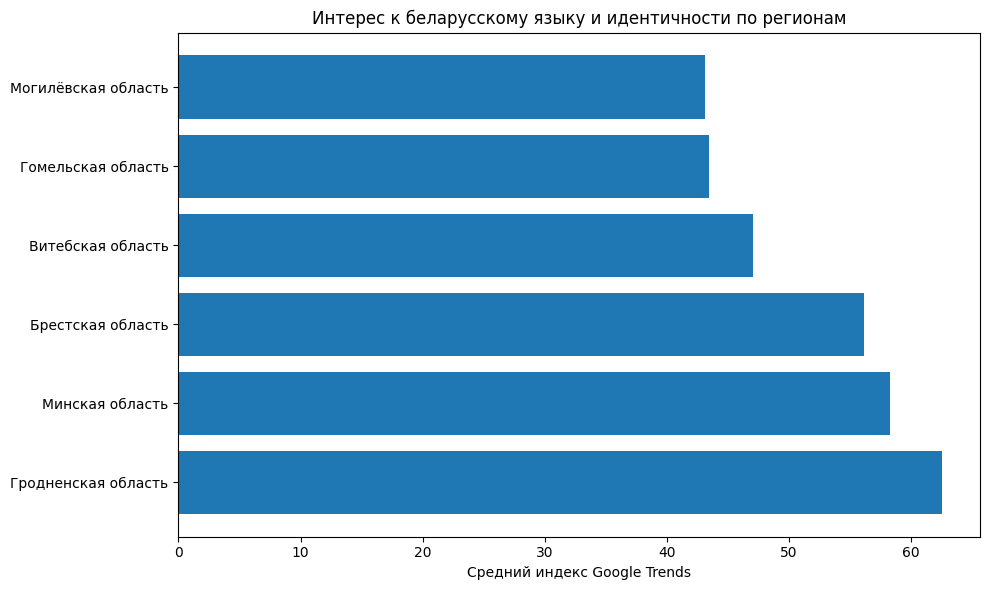

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(
    regional_interest["region"],
    regional_interest["interest"]
)

plt.title(
    "Интерес к беларусскому языку и идентичности по регионам"
)

plt.xlabel(
    "Средний индекс Google Trends"
)

plt.tight_layout()

plt.show()

## 20. Exporting regional results

The aggregated regional statistics are exported as a CSV file for future analysis.

In [30]:
regional_interest.to_csv("regional_interest.csv")

In [31]:
print(identity_yearly)

      year   interest
0   2015.0  15.541667
1   2016.0  13.580729
2   2017.0  14.604167
3   2018.0  14.484375
4   2019.0  14.458333
5   2020.0  16.992188
6   2021.0  14.716146
7   2022.0  22.221354
8   2023.0  21.067708
9   2024.0  19.005208
10  2025.0  18.843750
